In [1]:
import pandas as pd
import numpy as np

In [2]:
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

In [3]:
train_df = pd.read_csv("/Users/priyanshu.tuli/Desktop/machinehack/food_order_forecast/Dataset/Train.csv")

In [4]:
test_df = pd.read_csv("/Users/priyanshu.tuli/Desktop/machinehack/food_order_forecast/Dataset/Test.csv")

In [5]:
train_df.head()

,Period_No,Facility_No,Facility_Category,City_Zip_Code,Operational_Region_Coverage_Area,Billing_Amount,Labelled_Price,Custom_Promoted,Promoted,Search_Promotions,Orders_Count,Course,Flavour_Profile
0,1,324,c1,977,169,192.955562,267.971749,0,0,0,123,Finger Foods,Asian Fusion
1,1,10,c3,0,62,193.384864,203.836706,0,0,0,55,Broths & Stews,Asian Fusion
2,1,99,c3,0,167,384.988183,388.957411,0,0,0,204,Smoothies & Juices,Western
3,1,95,c3,17,2,255.251864,263.923874,0,0,0,257,Grain Bowls,South Asian
4,1,128,c3,17,18,319.949514,326.128813,0,0,0,14,Appetizers,Asian Fusion


In [6]:
train_df.shape

(321437, 13)

In [7]:
test_df.shape

(118070, 12)

In [8]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 321437 entries, 0 to 321436
Data columns (total 13 columns):
 #   Column                            Non-Null Count   Dtype  
---  ------                            --------------   -----  
 0   Period_No                         321437 non-null  int64  
 1   Facility_No                       321437 non-null  int64  
 2   Facility_Category                 321437 non-null  object 
 3   City_Zip_Code                     321437 non-null  int64  
 4   Operational_Region_Coverage_Area  321437 non-null  int64  
 5   Billing_Amount                    321437 non-null  float64
 6   Labelled_Price                    321437 non-null  float64
 7   Custom_Promoted                   321437 non-null  int64  
 8   Promoted                          321437 non-null  int64  
 9   Search_Promotions                 321437 non-null  int64  
 10  Orders_Count                      321437 non-null  int64  
 11  Course                            321437 non-null  o

In [9]:
test_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 118070 entries, 0 to 118069
Data columns (total 12 columns):
 #   Column                            Non-Null Count   Dtype  
---  ------                            --------------   -----  
 0   Period_No                         118070 non-null  int64  
 1   Facility_No                       118070 non-null  int64  
 2   Facility_Category                 118070 non-null  object 
 3   City_Zip_Code                     118070 non-null  int64  
 4   Operational_Region_Coverage_Area  118070 non-null  int64  
 5   Billing_Amount                    118070 non-null  float64
 6   Labelled_Price                    118070 non-null  float64
 7   Custom_Promoted                   118070 non-null  int64  
 8   Promoted                          118070 non-null  int64  
 9   Search_Promotions                 118070 non-null  int64  
 10  Course                            118070 non-null  object 
 11  Flavour_Profile                   118070 non-null  o

In [10]:
set(train_df.columns) - set(test_df.columns)

{'Orders_Count'}

In [11]:
train_df.describe().round(2)

,Period_No,Facility_No,City_Zip_Code,Operational_Region_Coverage_Area,Billing_Amount,Labelled_Price,Custom_Promoted,Promoted,Search_Promotions,Orders_Count
count,321437.00,321437.00,321437.00,321437.00,321437.00,321437.00,321437.00,321437.00,321437.00,321437.00
mean,50.05,420.23,271.28,418.08,331.62,362.64,0.08,0.11,0.07,261.53
std,28.78,1575.03,403.84,2662.50,154.06,163.47,0.28,0.31,0.25,383.79
min,1.00,3.00,0.00,1.00,51.21,59.94,0.00,0.00,0.00,13.00
25%,25.00,36.00,0.00,13.00,223.79,249.05,0.00,0.00,0.00,54.00
50%,50.00,78.00,17.00,48.00,297.27,318.98,0.00,0.00,0.00,136.00
75%,75.00,132.00,582.00,140.00,441.95,471.09,0.00,0.00,0.00,324.00
max,100.00,12390.00,977.00,23595.00,864.31,876.83,1.00,1.00,1.00,13150.00


In [12]:
train_df['Facility_Category'].value_counts()

Facility_Category
c1    184775
c3     69646
c2     67016
Name: count, dtype: int64

In [13]:
train_df['Facility_No'].value_counts()

Facility_No
63       4948
87       4925
13       4925
112      4898
36       4892
17       4885
426      4847
108      4843
56       4836
55       4800
24       4794
90       4774
43       4760
15       4721
45       4711
57       4706
46       4704
70       4673
23       4663
54       4640
101      4522
52       4511
9        4489
315      4474
18       4434
9256     4408
354      4388
82       4382
988      4314
10       4298
132      4295
80       4294
40       4288
42       4265
192      4257
1476     4227
7        4218
334      4217
111      4215
88       4205
5        4171
32       4169
1836     4149
28       4147
114      4132
98       4130
66       4130
324      4118
102      4117
19       4098
768      4090
498      4063
224      4041
665      3995
53       3937
666      3923
77       3908
12       3870
3        3847
72       3784
21       3767
456      3765
49       3699
4        3686
104      3681
6        3677
79       3671
99       3635
161      3535
856      3496
78      

In [14]:
train_df['City_Zip_Code'].value_counts()

City_Zip_Code
0      134451
17      81986
977     66360
582     21943
153      4511
863      4474
357      4041
601      3671
Name: count, dtype: int64

## Feature Engineering & Target Encoding

In [15]:
train_df['Facility_Category_per_zip'] = train_df.groupby('City_Zip_Code')['Facility_Category'].transform('nunique')

In [16]:
test_df['Facility_Category_per_zip'] = test_df.groupby('City_Zip_Code')['Facility_Category'].transform('nunique')

In [17]:
train_df['Difference_in_Order_Price'] = train_df['Billing_Amount'] - train_df['Labelled_Price']

In [18]:
test_df['Difference_in_Order_Price'] = test_df['Billing_Amount'] - test_df['Labelled_Price']

In [19]:
train_df['Difference_in_Order_Price'].describe().round(2)

count    321437.00
mean        -31.02
std          49.02
min        -550.90
25%         -17.11
50%         -10.45
75%          -7.71
max          -0.20
Name: Difference_in_Order_Price, dtype: float64

In [20]:
train_df['Mean_Orders_Count_per_Facility'] = train_df.groupby('Facility_No')['Orders_Count'].transform('mean')

In [21]:
train_df['Median_Orders_Count_per_Facility'] = train_df.groupby('Facility_No')['Orders_Count'].transform('median')

In [22]:
for i, group in train_df.groupby('Facility_No'):
    train_group = train_df[train_df['Facility_No'] == i]
    test_df.loc[test_df['Facility_No'] == i, 'Mean_Orders_Count_per_Facility'] = train_group['Orders_Count'].mean()
    test_df.loc[test_df['Facility_No'] == i, 'Median_Orders_Count_per_Facility'] = train_group['Orders_Count'].median()

In [23]:
train_df['Mean_Operational_Region_Coverage_Area_per_Facility_Category'] = train_df.groupby('Facility_Category')['Operational_Region_Coverage_Area'].transform('mean')
train_df['Median_Operational_Region_Coverage_Area_per_Facility_Category'] = train_df.groupby('Facility_Category')['Operational_Region_Coverage_Area'].transform('median')

In [24]:
test_df['Mean_Operational_Region_Coverage_Area_per_Facility_Category'] = test_df.groupby('Facility_Category')['Operational_Region_Coverage_Area'].transform('mean')
test_df['Median_Operational_Region_Coverage_Area_per_Facility_Category'] = test_df.groupby('Facility_Category')['Operational_Region_Coverage_Area'].transform('median')

In [25]:
train_df['Mean_Orders_Count_per_Facility_Category'] = train_df.groupby('Facility_Category')['Orders_Count'].transform('mean')
train_df['Median_Orders_Count_per_Facility_Category'] = train_df.groupby('Facility_Category')['Orders_Count'].transform('median')

In [26]:
for i, group in train_df.groupby('Facility_Category'):
    train_group = train_df[train_df['Facility_Category'] == i]
    test_df.loc[test_df['Facility_Category'] == i, 'Mean_Orders_Count_per_Facility_Category'] = train_group['Orders_Count'].mean()
    test_df.loc[test_df['Facility_Category'] == i, 'Median_Orders_Count_per_Facility_Category'] = train_group['Orders_Count'].median()

In [27]:
train_df['Mean_Orders_Count_per_City_Zip_Code'] = train_df.groupby('City_Zip_Code')['Orders_Count'].transform('mean')
train_df['Median_Orders_Count_per_City_Zip_Code'] = train_df.groupby('City_Zip_Code')['Orders_Count'].transform('median')

In [28]:
for i, group in train_df.groupby('City_Zip_Code'):
    train_group = train_df[train_df['City_Zip_Code'] == i]
    test_df.loc[test_df['City_Zip_Code'] == i, 'Mean_Orders_Count_per_City_Zip_Code'] = train_group['Orders_Count'].mean()
    test_df.loc[test_df['City_Zip_Code'] == i, 'Median_Orders_Count_per_City_Zip_Code'] = train_group['Orders_Count'].median()

In [29]:
train_df['Mean_Orders_Count_per_Facility_Category_per_zip'] = train_df.groupby(['Facility_Category', 'City_Zip_Code'])['Orders_Count'].transform('mean')
train_df['Median_Orders_Count_per_Facility_Category_per_zip'] = train_df.groupby(['Facility_Category', 'City_Zip_Code'])['Orders_Count'].transform('median')

In [30]:
for i, group in train_df.groupby(['Facility_Category', 'City_Zip_Code']):
    train_group = train_df[(train_df['Facility_Category'] == i[0]) & (train_df['City_Zip_Code'] == i[1])]
    test_df.loc[(test_df['Facility_Category'] == i[0]) & (test_df['City_Zip_Code'] == i[1]), 'Mean_Orders_Count_per_Facility_Category_per_zip'] = train_group['Orders_Count'].mean()
    test_df.loc[(test_df['Facility_Category'] == i[0]) & (test_df['City_Zip_Code'] == i[1]), 'Median_Orders_Count_per_Facility_Category_per_zip'] = train_group['Orders_Count'].median()

In [31]:
train_df['Billing_Amount'].describe().round(2)

count    321437.00
mean        331.62
std         154.06
min          51.21
25%         223.79
50%         297.27
75%         441.95
max         864.31
Name: Billing_Amount, dtype: float64

In [32]:
train_df['Labelled_Price'].describe().round(2)

count    321437.00
mean        362.64
std         163.47
min          59.94
25%         249.05
50%         318.98
75%         471.09
max         876.83
Name: Labelled_Price, dtype: float64

In [33]:
train_df['Billing_Amount_per_Facility'] = train_df.groupby('Facility_No')['Billing_Amount'].transform('mean')
train_df['Labelled_Price_per_Facility'] = train_df.groupby('Facility_No')['Labelled_Price'].transform('mean')

In [34]:
test_df['Billing_Amount_per_Facility'] = test_df.groupby('Facility_No')['Billing_Amount'].transform('mean')
test_df['Labelled_Price_per_Facility'] = test_df.groupby('Facility_No')['Labelled_Price'].transform('mean')

In [35]:
train_df['Billing_Amount_per_Facility_Category'] = train_df.groupby('Facility_Category')['Billing_Amount'].transform('mean')
train_df['Labelled_Price_per_Facility_Category'] = train_df.groupby('Facility_Category')['Labelled_Price'].transform('mean')

In [36]:
test_df['Billing_Amount_per_Facility_Category'] = test_df.groupby('Facility_Category')['Billing_Amount'].transform('mean')
test_df['Labelled_Price_per_Facility_Category'] = test_df.groupby('Facility_Category')['Labelled_Price'].transform('mean')

In [37]:
billing_quantiles = train_df['Billing_Amount'].quantile([0.25, 0.5, 0.75])

In [38]:
train_df['Billing_Amount_Category'] = pd.cut(train_df['Billing_Amount'], bins=[0, billing_quantiles[0.25], billing_quantiles[0.5], billing_quantiles[0.75], np.inf], labels=['Low', 'Medium', 'High', 'Very High'])

In [39]:
train_df.groupby('Billing_Amount_Category')['Billing_Amount'].describe().round(2)

/var/folders/pw/wmjkx07d5bj7gwx0bm5zkdjm0000gp/T/ipykernel_47300/2565369678.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  train_df.groupby('Billing_Amount_Category')['Billing_Amount'].describe().round(2)


,count,mean,std,min,25%,50%,75%,max
Billing_Amount_Category,,,,,,,,
Low,80360.0,156.56,34.17,51.21,140.10,155.04,184.95,223.79
Medium,80359.0,267.16,21.50,223.80,242.23,277.36,287.33,297.27
High,80359.0,352.10,45.22,297.27,316.17,329.48,386.71,441.95
Very High,80359.0,550.65,89.81,441.95,472.50,529.47,631.02,864.31


In [40]:
test_df['Billing_Amount_Category'] = pd.cut(test_df['Billing_Amount'], bins=[0, billing_quantiles[0.25], billing_quantiles[0.5], billing_quantiles[0.75], np.inf], labels=['Low', 'Medium', 'High', 'Very High'])

In [41]:
train_df['Labelled_Price_per_Facility_Category'] = train_df.groupby('Facility_Category')['Labelled_Price'].transform('mean')
train_df['Labelled_Price_per_City_Zip_Code'] = train_df.groupby('City_Zip_Code')['Labelled_Price'].transform('mean')

In [42]:
test_df['Labelled_Price_per_Facility_Category'] = test_df.groupby('Facility_Category')['Labelled_Price'].transform('mean')
test_df['Labelled_Price_per_City_Zip_Code'] = test_df.groupby('City_Zip_Code')['Labelled_Price'].transform('mean')

In [43]:
train_facility_category_ohe = pd.get_dummies(train_df['Facility_Category'], drop_first=True)
test_facility_category_ohe = pd.get_dummies(test_df['Facility_Category'], drop_first=True)

In [44]:
train_df = pd.concat([train_df, train_facility_category_ohe], axis=1)
test_df = pd.concat([test_df, test_facility_category_ohe], axis=1)

In [45]:
train_df.head()

,Period_No,Facility_No,Facility_Category,City_Zip_Code,Operational_Region_Coverage_Area,Billing_Amount,Labelled_Price,Custom_Promoted,Promoted,Search_Promotions,Orders_Count,Course,Flavour_Profile,Facility_Category_per_zip,Difference_in_Order_Price,Mean_Orders_Count_per_Facility,Median_Orders_Count_per_Facility,Mean_Operational_Region_Coverage_Area_per_Facility_Category,Median_Operational_Region_Coverage_Area_per_Facility_Category,Mean_Orders_Count_per_Facility_Category,Median_Orders_Count_per_Facility_Category,Mean_Orders_Count_per_City_Zip_Code,Median_Orders_Count_per_City_Zip_Code,Mean_Orders_Count_per_Facility_Category_per_zip,Median_Orders_Count_per_Facility_Category_per_zip,Billing_Amount_per_Facility,Labelled_Price_per_Facility,Billing_Amount_per_Facility_Category,Labelled_Price_per_Facility_Category,Billing_Amount_Category,Labelled_Price_per_City_Zip_Code,c2,c3
0,1,324,c1,977,169,192.955562,267.971749,0,0,0,123,Finger Foods,Asian Fusion,3,-75.016187,207.096163,134.0,119.148943,41.0,261.319199,136.0,215.997107,134.0,222.668917,135.0,338.306075,368.730776,332.258778,363.200445,Low,364.027076,False,False
1,1,10,c3,0,62,193.384864,203.836706,0,0,0,55,Broths & Stews,Asian Fusion,3,-10.451841,257.586087,109.0,123.774689,62.0,209.736984,107.0,318.114131,161.0,211.156378,96.0,327.379939,361.467997,323.127058,355.406857,Low,361.322642,False,True
2,1,99,c3,0,167,384.988183,388.957411,0,0,0,204,Smoothies & Juices,Western,3,-3.969227,160.554058,95.0,123.774689,62.0,209.736984,107.0,318.114131,161.0,211.156378,96.0,325.703747,360.549926,323.127058,355.406857,High,361.322642,False,True
3,1,95,c3,17,2,255.251864,263.923874,0,0,0,257,Grain Bowls,South Asian,3,-8.672010,200.477461,108.0,123.774689,62.0,209.736984,107.0,203.351487,122.0,192.056490,107.0,318.949795,349.521054,323.127058,355.406857,Medium,364.340836,False,True
4,1,128,c3,17,18,319.949514,326.128813,0,0,0,14,Appetizers,Asian Fusion,3,-6.179299,168.157716,95.0,123.774689,62.0,209.736984,107.0,203.351487,122.0,192.056490,107.0,312.061114,342.881173,323.127058,355.406857,High,364.340836,False,True


In [46]:
train_df['Billing_Amount_Category_Ordinal'] = train_df['Billing_Amount_Category'].map({'Low': 0, 'Medium': 1, 'High': 2, 'Very High': 3})
test_df['Billing_Amount_Category_Ordinal'] = test_df['Billing_Amount_Category'].map({'Low': 0, 'Medium': 1, 'High': 2, 'Very High': 3})

In [47]:
train_df['Course'].value_counts(normalize=True)

Course
Smoothies & Juices      0.274900
Grain Bowls             0.071358
Wraps & Rolls           0.071227
Fresh Greens            0.071087
Flatbreads              0.070866
Finger Foods            0.065005
Appetizers              0.063409
Sweets & Treats         0.063291
Plant-Based Proteins    0.058761
Noodles & Veggies       0.057868
Stir-Fried Rice         0.043999
Grilled Vegetables      0.031487
Condiments & Dips       0.029088
Broths & Stews          0.027654
Name: proportion, dtype: float64

In [48]:
train_df['Mean_Orders_Count_per_Course'] = train_df.groupby('Course')['Orders_Count'].transform('mean')
train_df['Median_Orders_Count_per_Course'] = train_df.groupby('Course')['Orders_Count'].transform('median')

In [49]:
for i, group in train_df.groupby('Course'):
    train_group = train_df[train_df['Course'] == i]
    test_df.loc[test_df['Course'] == i, 'Mean_Orders_Count_per_Course'] = train_group['Orders_Count'].mean()
    test_df.loc[test_df['Course'] == i, 'Median_Orders_Count_per_Course'] = train_group['Orders_Count'].median()

In [50]:
train_df['Mean_Billing_Amount_per_Course'] = train_df.groupby('Course')['Billing_Amount'].transform('mean')
train_df['Median_Billing_Amount_per_Course'] = train_df.groupby('Course')['Billing_Amount'].transform('median')
train_df['Mean_Labelled_Price_per_Course'] = train_df.groupby('Course')['Labelled_Price'].transform('mean')
train_df['Median_Labelled_Price_per_Course'] = train_df.groupby('Course')['Labelled_Price'].transform('median')

In [51]:
test_df['Mean_Billing_Amount_per_Course'] = test_df.groupby('Course')['Billing_Amount'].transform('mean')
test_df['Median_Billing_Amount_per_Course'] = test_df.groupby('Course')['Billing_Amount'].transform('median')
test_df['Mean_Labelled_Price_per_Course'] = test_df.groupby('Course')['Labelled_Price'].transform('mean')
test_df['Median_Labelled_Price_per_Course'] = test_df.groupby('Course')['Labelled_Price'].transform('median')

In [52]:
train_df["Mean_Billing_Amount_per_Course_per_City_Zip_Code"] = train_df.groupby(['Course', 'City_Zip_Code'])['Billing_Amount'].transform('mean')
train_df["Median_Billing_Amount_per_Course_per_City_Zip_Code"] = train_df.groupby(['Course', 'City_Zip_Code'])['Billing_Amount'].transform('median')
train_df["Mean_Labelled_Price_per_Course_per_City_Zip_Code"] = train_df.groupby(['Course', 'City_Zip_Code'])['Labelled_Price'].transform('mean')
train_df["Median_Labelled_Price_per_Course_per_City_Zip_Code"] = train_df.groupby(['Course', 'City_Zip_Code'])['Labelled_Price'].transform('median')

In [53]:
test_df["Mean_Billing_Amount_per_Course_per_City_Zip_Code"] = test_df.groupby(['Course', 'City_Zip_Code'])['Billing_Amount'].transform('mean')
test_df["Median_Billing_Amount_per_Course_per_City_Zip_Code"] = test_df.groupby(['Course', 'City_Zip_Code'])['Billing_Amount'].transform('median')
test_df["Mean_Labelled_Price_per_Course_per_City_Zip_Code"] = test_df.groupby(['Course', 'City_Zip_Code'])['Labelled_Price'].transform('mean')
test_df["Median_Labelled_Price_per_Course_per_City_Zip_Code"] = test_df.groupby(['Course', 'City_Zip_Code'])['Labelled_Price'].transform('median')

In [54]:
train_df['Mean_Billing_Amount_per_Course_per_Facility_Category'] = train_df.groupby(['Course', 'Facility_Category'])['Billing_Amount'].transform('mean')
train_df['Median_Billing_Amount_per_Course_per_Facility_Category'] = train_df.groupby(['Course', 'Facility_Category'])['Billing_Amount'].transform('median')
train_df['Mean_Labelled_Price_per_Course_per_Facility_Category'] = train_df.groupby(['Course', 'Facility_Category'])['Labelled_Price'].transform('mean')
train_df['Median_Labelled_Price_per_Course_per_Facility_Category'] = train_df.groupby(['Course', 'Facility_Category'])['Labelled_Price'].transform('median')

In [55]:
test_df['Mean_Billing_Amount_per_Course_per_Facility_Category'] = test_df.groupby(['Course', 'Facility_Category'])['Billing_Amount'].transform('mean')
test_df['Median_Billing_Amount_per_Course_per_Facility_Category'] = test_df.groupby(['Course', 'Facility_Category'])['Billing_Amount'].transform('median')
test_df['Mean_Labelled_Price_per_Course_per_Facility_Category'] = test_df.groupby(['Course', 'Facility_Category'])['Labelled_Price'].transform('mean')
test_df['Median_Labelled_Price_per_Course_per_Facility_Category'] = test_df.groupby(['Course', 'Facility_Category'])['Labelled_Price'].transform('median')

In [56]:
train_df['Flavour_Profile'].value_counts()

Flavour_Profile
Mediterranean    87284
Asian Fusion     82002
South Asian      77920
Western          74231
Name: count, dtype: int64

In [57]:
train_df['Course_per_Flavour_Profile'] = train_df.groupby('Flavour_Profile')['Course'].transform('nunique')
test_df['Course_per_Flavour_Profile'] = test_df.groupby('Flavour_Profile')['Course'].transform('nunique')

In [58]:
train_df['Mean_Billing_Amount_per_Flavour_Profile'] = train_df.groupby('Flavour_Profile')['Billing_Amount'].transform('mean')
train_df['Median_Billing_Amount_per_Flavour_Profile'] = train_df.groupby('Flavour_Profile')['Billing_Amount'].transform('median')
test_df['Mean_Billing_Amount_per_Flavour_Profile'] = test_df.groupby('Flavour_Profile')['Billing_Amount'].transform('mean')
test_df['Median_Billing_Amount_per_Flavour_Profile'] = test_df.groupby('Flavour_Profile')['Billing_Amount'].transform('median')

In [59]:
train_df['Mean_Labelled_Price_per_Flavour_Profile'] = train_df.groupby('Flavour_Profile')['Labelled_Price'].transform('mean')
train_df['Median_Labelled_Price_per_Flavour_Profile'] = train_df.groupby('Flavour_Profile')['Labelled_Price'].transform('median')
test_df['Mean_Labelled_Price_per_Flavour_Profile'] = test_df.groupby('Flavour_Profile')['Labelled_Price'].transform('mean')
test_df['Median_Labelled_Price_per_Flavour_Profile'] = test_df.groupby('Flavour_Profile')['Labelled_Price'].transform('median')

In [60]:
train_flavour_profile_ohe = pd.get_dummies(train_df['Flavour_Profile'], drop_first=True)
test_flavour_profile_ohe = pd.get_dummies(test_df['Flavour_Profile'], drop_first=True)

In [61]:
train_df = pd.concat([train_df, train_flavour_profile_ohe], axis=1)
test_df = pd.concat([test_df, test_flavour_profile_ohe], axis=1)

In [62]:
train_df['Discount_Provided'] = np.where(train_df['Difference_in_Order_Price'] < 0, 1, 0)
test_df['Discount_Provided'] = np.where(test_df['Difference_in_Order_Price'] < 0, 1, 0)

In [63]:
train_df['Discount_Provided'].value_counts(normalize=True)

Discount_Provided
1    1.0
Name: proportion, dtype: float64

In [64]:
test_df['Discount_Provided'].value_counts(normalize=True)

Discount_Provided
1    1.0
Name: proportion, dtype: float64

In [65]:
train_df['Mean_Discount_Provided_per_Facility'] = train_df.groupby('Facility_No')['Discount_Provided'].transform('mean')
train_df['Median_Discount_Provided_per_Facility'] = train_df.groupby('Facility_No')['Discount_Provided'].transform('median')
test_df['Mean_Discount_Provided_per_Facility'] = test_df.groupby('Facility_No')['Discount_Provided'].transform('mean')
test_df['Median_Discount_Provided_per_Facility'] = test_df.groupby('Facility_No')['Discount_Provided'].transform('median')

In [66]:
train_df['Discount_Percentage'] = (train_df['Difference_in_Order_Price'] / train_df['Labelled_Price']) * 100
test_df['Discount_Percentage'] = (test_df['Difference_in_Order_Price'] / test_df['Labelled_Price']) * 100

In [67]:
train_course_categories = train_df['Course'].value_counts(normalize=True, sort='descending').index[:5]

In [68]:
train_course_categories

Index(['Smoothies & Juices', 'Grain Bowls', 'Wraps & Rolls', 'Fresh Greens',
       'Flatbreads'],
      dtype='object', name='Course')

In [69]:
train_df['Course_Category'] = np.where(train_df['Course'].isin(train_course_categories), train_df['Course'], 'Other')
test_df['Course_Category'] = np.where(test_df['Course'].isin(train_course_categories), test_df['Course'], 'Other')

In [77]:
train_course_categories_ohe = pd.get_dummies(train_df['Course_Category'], drop_first=True)
test_course_categories_ohe = pd.get_dummies(test_df['Course_Category'], drop_first=True)

In [78]:
train_df = pd.concat([train_df, train_course_categories_ohe], axis=1)
test_df = pd.concat([test_df, test_course_categories_ohe], axis=1)

## Model Training

In [79]:
from sklearn.model_selection import train_test_split
from xgboost import XGBRegressor

In [80]:
selected_train_df = train_df.drop(['Course', 'Flavour_Profile', 'Facility_Category', 'Billing_Amount_Category', 'Course_Category'], axis=1)

In [81]:
selected_test_df = test_df.drop(['Course', 'Flavour_Profile', 'Facility_Category', 'Billing_Amount_Category', 'Course_Category'], axis=1)

In [82]:
selected_train_df['Billing_Amount_Category_Ordinal'] = selected_train_df['Billing_Amount_Category_Ordinal'].astype(float)
selected_test_df['Billing_Amount_Category_Ordinal'] = selected_test_df['Billing_Amount_Category_Ordinal'].astype(float)

In [83]:
selected_train_df.select_dtypes(include='object').columns

Index([], dtype='object')

In [84]:
selected_test_df.select_dtypes(include='object').columns

Index([], dtype='object')

In [85]:
selected_train_df.shape, selected_test_df.shape

((321437, 61), (118070, 60))

In [86]:
set(selected_train_df.columns) - set(selected_test_df.columns)

{'Orders_Count'}

In [87]:
X_train, X_val, y_train, y_val = train_test_split(selected_train_df.drop(['Orders_Count'], axis=1), selected_train_df['Orders_Count'], test_size=0.1, random_state=42, shuffle=True)

In [88]:
X_train.shape, X_val.shape

((289293, 60), (32144, 60))

In [89]:
model = XGBRegressor(n_estimators=400, max_depth=10, learning_rate=0.1, random_state=42, n_jobs=-1, objective='reg:squarederror', alpha=0.1, colsample_bytree=0.6, subsample=0.8, \
                     eval_metric='rmse', reg_lambda=1) 

In [90]:
model.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=10)

[0]	validation_0-rmse:363.28973
[10]	validation_0-rmse:221.76134
[20]	validation_0-rmse:182.61452
[30]	validation_0-rmse:170.19697
[40]	validation_0-rmse:163.24742
[50]	validation_0-rmse:159.44270
[60]	validation_0-rmse:157.05628
[70]	validation_0-rmse:155.51352
[80]	validation_0-rmse:154.21722
[90]	validation_0-rmse:153.51260
[100]	validation_0-rmse:152.66895
[110]	validation_0-rmse:152.30895
[120]	validation_0-rmse:152.01812
[130]	validation_0-rmse:151.45765
[140]	validation_0-rmse:151.11043
[150]	validation_0-rmse:150.85712
[160]	validation_0-rmse:150.57690
[170]	validation_0-rmse:150.34976
[180]	validation_0-rmse:150.14227
[190]	validation_0-rmse:149.94515
[200]	validation_0-rmse:149.64564
[210]	validation_0-rmse:149.50384
[220]	validation_0-rmse:149.49667
[230]	validation_0-rmse:149.40571
[240]	validation_0-rmse:149.29379
[250]	validation_0-rmse:149.27293
[260]	validation_0-rmse:149.17911
[270]	validation_0-rmse:149.13947
[280]	validation_0-rmse:149.12649
[290]	validation_0-rmse:1

XGBRegressor(alpha=0.1, base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.6, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric='rmse', feature_types=None,
             gamma=None, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=0.1, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=10, max_leaves=None,
             min_child_weight=None, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=400, n_jobs=-1,
             num_parallel_tree=None, ...)

In [91]:
from xgboost import plot_importance

In [92]:
import matplotlib.pyplot as plt

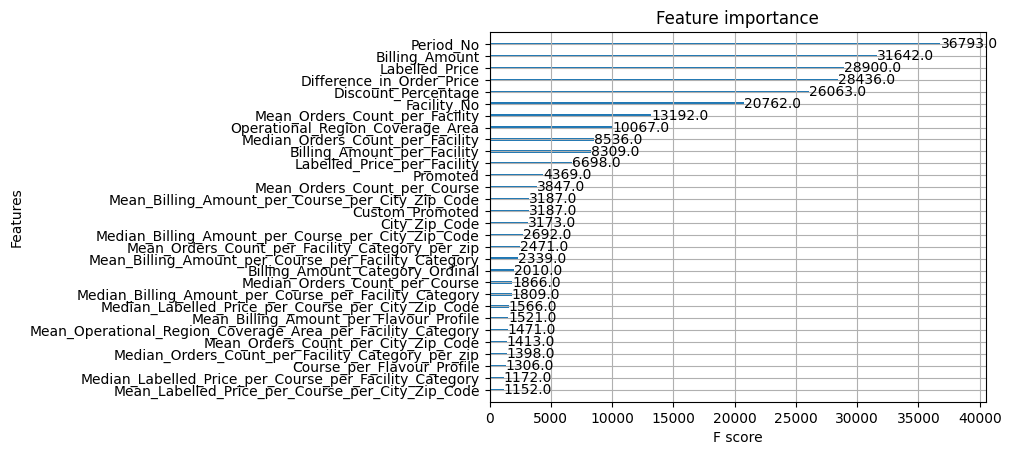

In [94]:
plot_importance(model, max_num_features=30)
plt.show()

In [95]:
model.fit(selected_train_df.drop(['Orders_Count'], axis=1), selected_train_df['Orders_Count'])

XGBRegressor(alpha=0.1, base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.6, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric='rmse', feature_types=None,
             gamma=None, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=0.1, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=10, max_leaves=None,
             min_child_weight=None, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=400, n_jobs=-1,
             num_parallel_tree=None, ...)

In [96]:
test_df['Orders_Count'] = model.predict(selected_test_df)

In [97]:
test_df['Orders_Count'].describe()

count    118070.000000
mean        236.927948
std         277.246796
min        -220.894363
25%          57.705103
50%         142.514839
75%         319.877625
max        5159.465332
Name: Orders_Count, dtype: float64

In [98]:
min(train_df['Orders_Count'])

13

In [99]:
test_df.loc[np.floor(test_df['Orders_Count']) <= 0, 'Orders_Count'] = min(train_df['Orders_Count'])

In [100]:
test_df['Orders_Count'].describe()

count    118070.000000
mean        237.145462
std         277.053162
min           1.002705
25%          57.705103
50%         142.514839
75%         319.877625
max        5159.465332
Name: Orders_Count, dtype: float64

In [101]:
test_df['Orders_Count'] = np.round(test_df['Orders_Count'],0)

In [102]:
test_df['Orders_Count'].describe()

count    118070.000000
mean        237.143890
std         277.053528
min           1.000000
25%          58.000000
50%         143.000000
75%         320.000000
max        5159.000000
Name: Orders_Count, dtype: float64

In [103]:
train_df['Orders_Count'].describe()

count    321437.000000
mean        261.533790
std         383.785233
min          13.000000
25%          54.000000
50%         136.000000
75%         324.000000
max       13150.000000
Name: Orders_Count, dtype: float64

In [104]:
test_df["Orders_Count"].to_csv("/Users/priyanshu.tuli/Desktop/machinehack/food_order_forecast/Dataset/Submission.csv", index=False)